In [ ]:
# Housing Price

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_prep import (
    add_date_parts,
    add_house_age,
    add_price_per_sqft,
    add_price_segment,
    load_data,
    remove_price_outliers,
 )

sns.set_style("whitegrid")

In [ ]:
df = load_data()

In [7]:
df.shape
df.info()
df.describe()
df.isnull().sum()
pd.options.display.float_format = '{:,.2f}'.format

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           21613 non-null  int64  
 1   date         21613 non-null  object 
 2   price        21613 non-null  int64  
 3   bedrooms     21613 non-null  int64  
 4   bathrooms    21613 non-null  float64
 5   sqft_living  21613 non-null  int64  
 6   sqft_lot     21613 non-null  int64  
 7   floors       21613 non-null  float64
 8   waterfront   21613 non-null  int64  
 9   view         21613 non-null  int64  
 10  condition    21613 non-null  int64  
 11  grade        21613 non-null  int64  
 12  yr_built     21613 non-null  int64  
 13  zipcode      21613 non-null  int64  
 14  lat          21613 non-null  float64
 15  long         21613 non-null  float64
dtypes: float64(4), int64(11), object(1)
memory usage: 2.6+ MB


### Date Conversion and Time features

In [ ]:
df = add_date_parts(df)

### Market Overview - Price Distribution

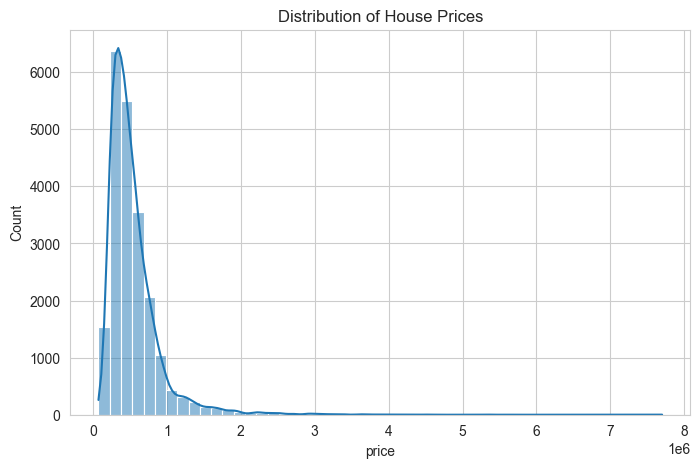

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df["price"], bins=50, kde=True)
plt.title("Distribution of House Prices")
plt.show()

### Key Insights

* Most houses are in the lower–mid price range
* A small number of houses are extremely expensive
* Those few luxury homes stretch the distribution

#### Conclusion :- King County has many moderately priced homes and a small number of ultra-luxury properties

### Mean vs Meridian of Housing Prices

In [10]:
print("Mean Price:", df["price"].mean())
print("Median Price:", df["price"].median())

Mean Price: 540088.1417665294
Median Price: 450000.0


### Remove Extreme Luxury Outliers (Top 1%)

In [ ]:
df_clean = remove_price_outliers(df)

##  Key Price Drivers

### Living Area Impact

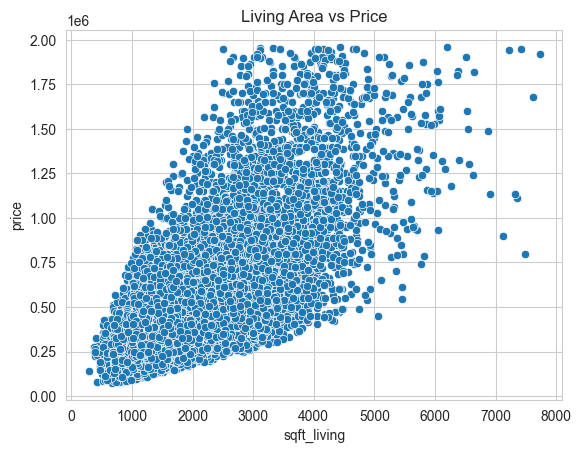

In [12]:
sns.scatterplot(x="sqft_living", y="price", data=df_clean)
plt.title("Living Area vs Price")
plt.show()

### Key Insights:

* This is showing a strong positive linear relationship
* As sqft_living increases then price also increases.

#### Conclusion :- Living area is one of the strongest predictors of house price

### Bedrooms Impact

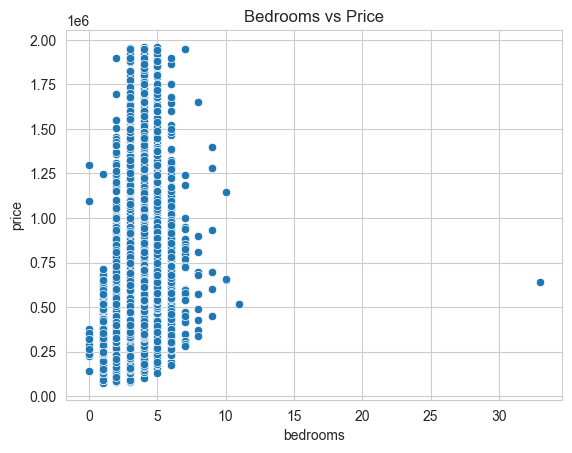

In [13]:
sns.scatterplot(x="bedrooms", y="price", data=df_clean)
plt.title("Bedrooms vs Price")
plt.show()

### Bathrooms Impact

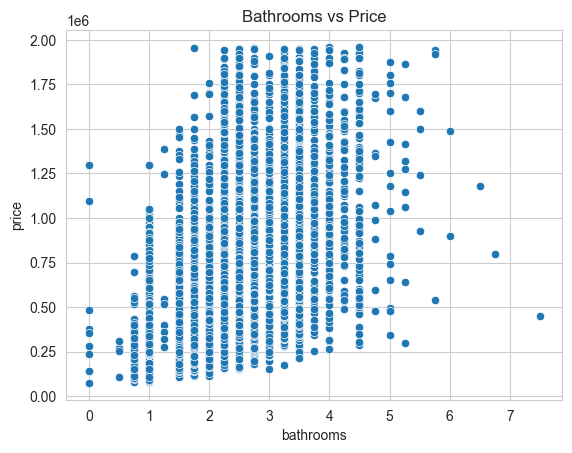

In [14]:
sns.scatterplot(x="bathrooms", y="price", data=df_clean)
plt.title("Bathrooms vs Price")
plt.show()

### Key Insights:

* Clear Positive Relationship (But Not Perfect)
* As bathrooms increase, price generally increases.
* 3–4 Bathrooms Is the Sweet Spot

### Grade Impact

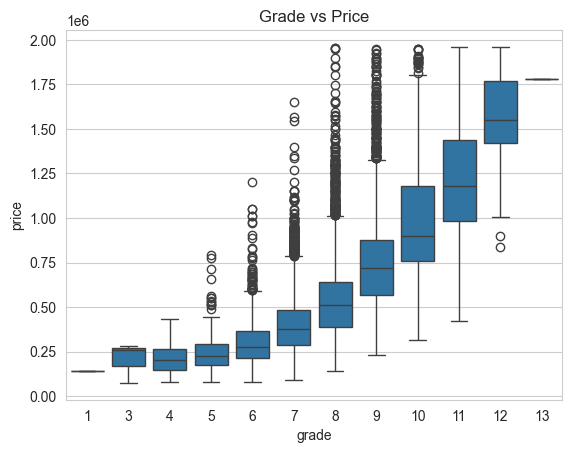

In [15]:
sns.boxplot(x="grade", y="price", data=df_clean)
plt.title("Grade vs Price")
plt.show()

### Key Insights:

* This also shows a strong linear relationship. 
* As construction quality or grade increases similary price also increases.
* Grade 7-8-9 has highest number of buyers across all types of price range.
* Grade 7-8-9 will provide the highest ROI

### Condition Impact

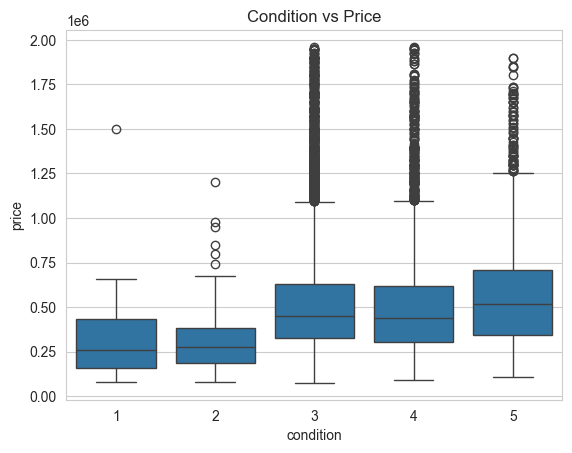

In [16]:
sns.boxplot(x="condition", y="price", data=df_clean)
plt.title("Condition vs Price")
plt.show()

### Key Insight:

* This is simple relation. As condition increases the value increases. Mid condition of 3 and 4 provides the best value

### View Rating vs Price

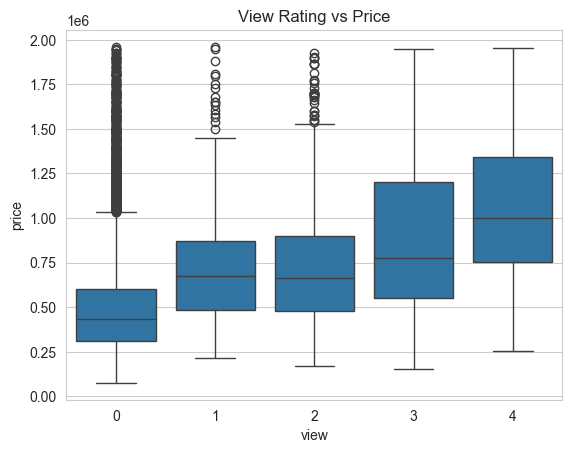

In [17]:
sns.boxplot(x="view", y="price", data=df_clean)
plt.title("View Rating vs Price")
plt.show()

### Key Insights:

* Direct Correlation Between View Quality and Price
* There is a clear, positive trend: as the view rating increases, the median price (the horizontal line inside each blue box) also rises.

### Price per sq.foot

In [ ]:
df_clean = add_price_per_sqft(df_clean)

df_clean["price_per_sqft"].mean()

np.float64(261.1561613040457)

### Price per sq.foot differentiated by zipcode

In [19]:
df_clean.groupby("zipcode")["price_per_sqft"].mean().sort_values(ascending=False).head(10)

zipcode
98039   543.60
98004   463.46
98109   430.77
98112   426.83
98119   423.58
98102   418.04
98105   399.07
98107   381.12
98040   372.69
98199   372.58
Name: price_per_sqft, dtype: float64

### Geographic Analysis

### Top 10 Expensive zipcodes

In [20]:
zip_avg = df_clean.groupby("zipcode")["price"].mean().sort_values(ascending=False)

zip_avg.head(10)

zipcode
98039   1,454,439.66
98004   1,147,426.87
98040   1,065,934.51
98112     938,920.01
98109     839,055.84
98006     811,973.34
98005     810,164.88
98105     804,878.28
98119     777,383.15
98102     776,556.18
Name: price, dtype: float64

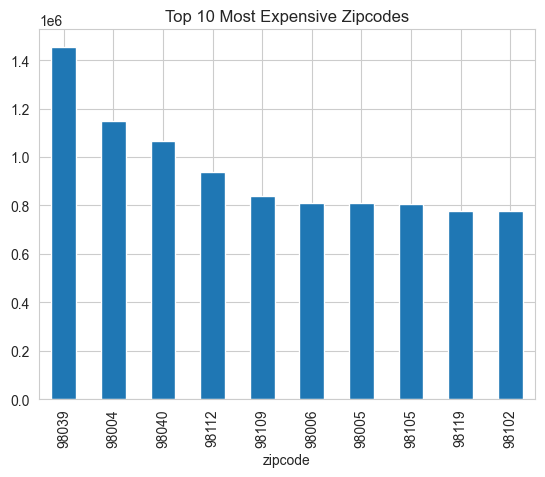

In [21]:
zip_avg.head(10).plot(kind="bar")
plt.title("Top 10 Most Expensive Zipcodes")
plt.show()

### Geographic Price Clusters

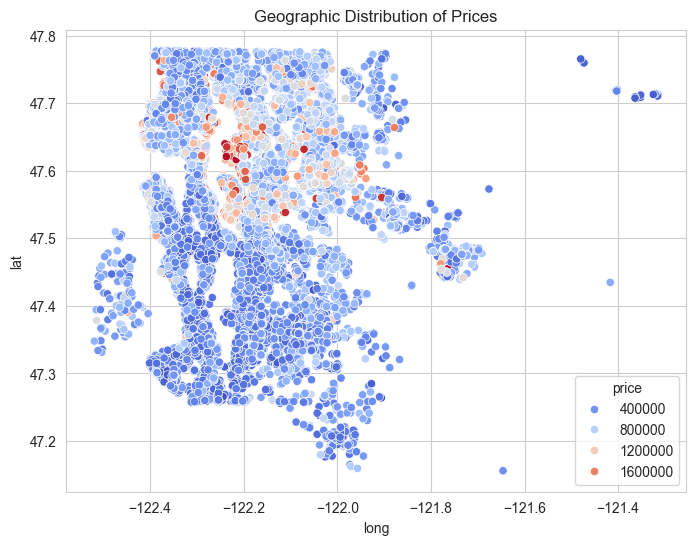

In [22]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="long",
    y="lat",
    hue="price",
    data=df_clean,
    palette="coolwarm"
)
plt.title("Geographic Distribution of Prices")
plt.show()

### Property Age Impact:

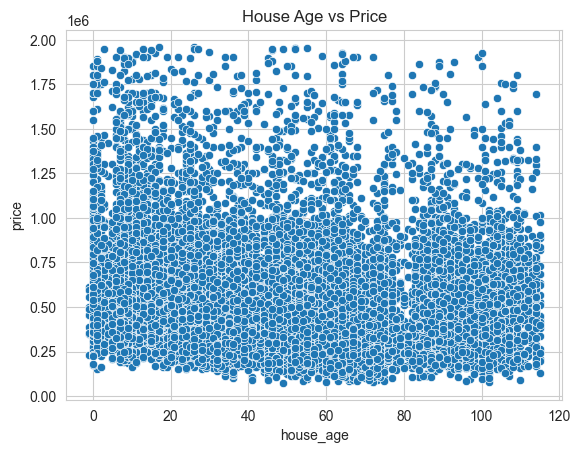

In [ ]:
df_clean = add_house_age(df_clean)
sns.scatterplot(x="house_age", y="price", data=df_clean)
plt.title("House Age vs Price")
plt.show()

### Key Insights:

* House age doesn't show a strong liner relationship and is not a strong predictor of price. 
* We will probably achieve weak correlation (maybe even slightly negative)
* We do see a little bit of insight that very new houses has higher price trend

### Market Segmentation : Creating Price Segments

In [ ]:
df_clean = add_price_segment(df_clean)
df_clean["price_segment"].value_counts()

price_segment
Low     7226
Mid     7091
High    7079
Name: count, dtype: int64

### Key Observations:

* Budget housing market = 7226
* Mid-tier housing market = 7091
* Premium housing market = 7079

### Key Insights:

* Cross Analysis (Bedrooms × Grade)
* This shows how bedroom impact changes depending on construction quality

In [25]:
pd.pivot_table(
    df_clean,
    values="price",
    index="bedrooms",
    columns="grade",
    aggfunc="median"
)

grade,1,3,4,5,6,7,8,9,10,11,12,13
bedrooms,,,,,,,,,,,,
0,"142,000.00",NaN,"246,500.00",NaN,NaN,"264,000.00","355,000.00",NaN,NaN,NaN,"1,295,650.00",NaN
1,NaN,"262,000.00","208,525.00","245,000.00","290,000.00","351,500.00","379,500.00","533,250.00","316,000.00",NaN,NaN,NaN
2,NaN,NaN,"176,000.00","215,400.00","280,000.00","400,000.00","465,000.00","644,500.00","890,000.00","1,145,785.00","1,899,000.00",NaN
3,NaN,NaN,"205,000.00","216,072.00","260,000.00","350,000.00","490,000.00","660,000.00","845,000.00","1,150,000.00","1,520,000.00",NaN
4,NaN,NaN,NaN,"247,000.00","303,000.00","400,000.00","539,725.00","725,747.50","879,000.00","1,150,000.00","1,580,000.00","1,780,000.00"
5,NaN,NaN,NaN,"325,000.00","365,000.00","430,000.00","575,000.00","830,000.00","1,095,000.00","1,240,000.00","1,481,500.00",NaN
6,NaN,NaN,NaN,"300,000.00","387,500.00","457,250.00","650,000.00","900,000.00","1,300,000.00","1,180,000.00","1,680,000.00",NaN
7,NaN,NaN,NaN,NaN,"580,000.00","475,000.00","598,578.50","974,500.00","936,000.00","1,375,000.00",NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,"627,500.00","490,000.00","1,650,000.00",NaN,NaN,NaN,NaN


### Key Insights:

* We Conclude that GRADE 7,8,9 construction properties has the maximum value overall irrespective of the number of bedroom provided
* Grade 7 level construction propperties provides the most value

### Monthly Market Trends 

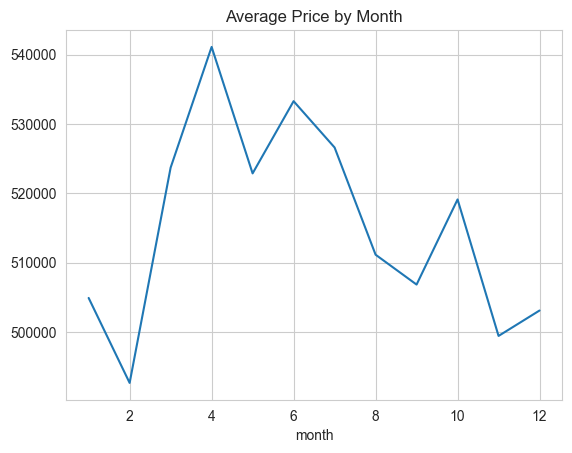

In [26]:
monthly_avg = df_clean.groupby("month")["price"].mean()

monthly_avg.plot()
plt.title("Average Price by Month")
plt.show()

### Key Insights:

* Months 4-6 provides the best time for selling. 
* With the average price peaking around month 4.
* Strongest time to sell properties.

### Correlation Analysis

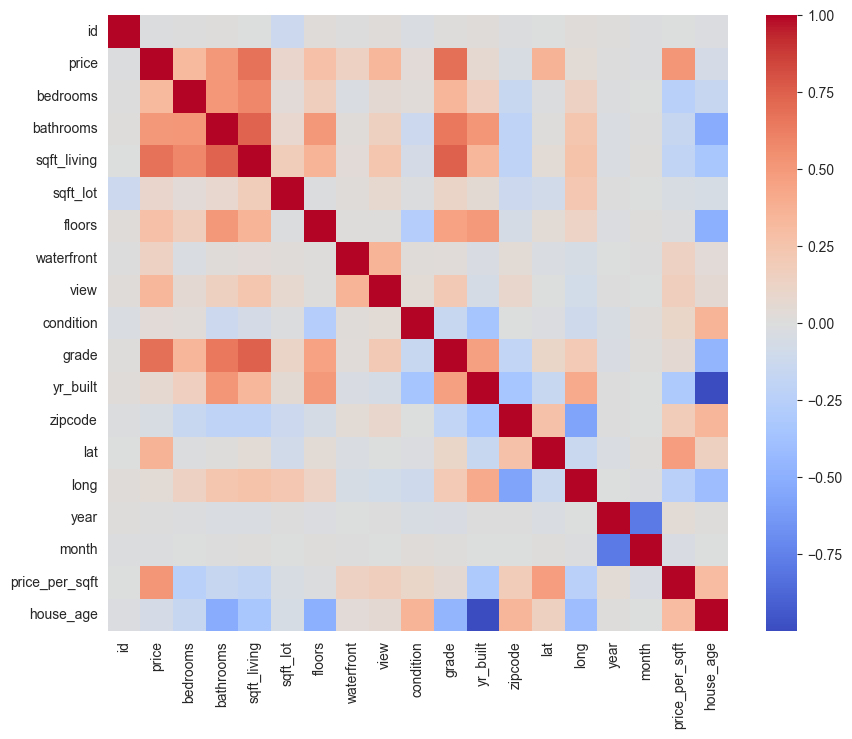

In [27]:
plt.figure(figsize=(10,8))
sns.heatmap(df_clean.corr(numeric_only=True), cmap="coolwarm")
plt.show()

### The strongest positive correlations appear to be:

* sqft_living (very strong)
* grade (very strong)
* bathrooms (strong)
* price_per_sqft (strong, obviously)
* view (moderate)
* waterfront (moderate to strong)

### Key Insights:

* Bedrooms correlation with price is much weaker than sqft_living or bathrooms because bedrooms do not provide value beyond space
* A 2000 sqft house with 3 bedrooms vs 4 bedrooms:
* The square footage matters more than the bedroom count
* Grade has very strong positive correlation with:price,sqft_living,bathrooms
* That means: Higher construction quality → bigger homes → higher price.
* Looking at zipcode,latitude and longitude we realize that there is a noticeable correlation with price and price_per_sqft.
* Same sq.foot but different zipcode and different location has significantly difference price range
* Which proves that Location is a highly significant factor in driving price range
* Premium Location provides Premium Price
* House age has negative correlation with price which was also derived earlier. Which concludes house age doesn't provide much value

### Key Findings:

* Living area is the strongest driver of house prices.
* Grade significantly impacts valuation, more than condition.
* Waterfront properties command a substantial price premium.
* Certain zipcodes dominate high-end housing market.
* Market shows moderate seasonal variation.
* Luxury outliers heavily skew overall pricing.